# **LONG STEPS in GRADIENT DESCENT METHODS**

## **Install**

### Firedrake

In [24]:
try:
    import google.colab  # noqa: F401
except ImportError:
    from firedrake import *
else:
    try:
        from firedrake import *
    except ImportError:
        !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh"
        !bash "/tmp/firedrake-install.sh"
        from firedrake import *

### Other

In [78]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

## **General functions**

### Constrained optimisation Firedrake code

In [97]:
def constrained_optimisation(nx=32, degree=4, gamma=2**32, max_iters=20, plot=True):
    # UFL-ify gamma
    gamma = Constant(gamma)

    # Mesh
    mesh = UnitSquareMesh(nx, nx, quadrilateral=True)
    V = FunctionSpace(mesh, "Q", degree)

    # Constraint function f(x, y): circular bump
    x, y = SpatialCoordinate(mesh)
    cylinders = (
        ((0.4, 0.7), 0.2, 1.0),
        ((0.8, 0.2), 0.1, 1.0),
    )
    f = sum([
        conditional((x - center[0])**2 + (y - center[1])**2 <= width**2, height, 0.0)
    for (center, width, height) in cylinders])

    # Functions
    u = Function(V)
    u_ = Function(V)
    v = TestFunction(V)

    # BCs
    bcs = DirichletBC(V, 0.0, "on_boundary")

    # Energy
    h1_norm = 0.5 * inner(grad(u_), grad(u_)) * dx
    constraint_viol = 0.5 * conditional(lt(u_, f), (u_ - f)**2, 0) * dx
    E = h1_norm + gamma * constraint_viol

    # Residual
    F = (
        inner(grad(u), grad(v))
      + gamma * conditional(lt(u_, f), (u - f) * v, 0)
    ) * dx

    # Newton's method
    energy = assemble(E)
    energies = [energy]
    print(GREEN % f"Energy: {energy}")
    for k in range(max_iters):
        print(BLUE % f"Newton iterate {k+1}...")
        solve(F == 0, u, bcs)
        u_.assign(u)
        energy = assemble(E)
        energies += [energy]
        print(GREEN % f"Energy: {energy}")

    if plot:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

        # Left: log energy error convergence
        energy_exact = min(energies) - 1e0
        energy_errors = [abs(energy - energy_exact) for energy in energies]

        ax1.semilogy(range(len(energy_errors)), energy_errors, marker='o', label='|E_k - E_*|')
        ax1.set_xlabel("Newton iterate")
        ax1.set_title("Energy errors")
        ax1.grid(True, which="both", ls="--", alpha=0.6)
        ax1.legend()

        # Right: contour plot
        tpc = tripcolor(u, axes=ax2)
        # Create contour lines
        cntr = tricontour(u, levels=10, colors='w', linewidths=1.0, axes=ax2)
        ax2.clabel(cntr, fmt="%.2f", fontsize=8)   # <-- Label contour values
        ax2.set_aspect('equal')
        ax2.set_title("Contour plot")
        fig.colorbar(tpc, ax=ax2, orientation='vertical')
        for (center, width, height) in cylinders:
            circ = Circle(center, width, fill=False, color='black', linestyle='--', linewidth=1.0)
            ax2.add_patch(circ)

        plt.tight_layout()
        plt.show()

    return u, energies

## **Motivation:** When Newton fails

We're all used to using Newton, and who can blame us?

When it works, the convergence is superb ($\mathcal{O}(C^{- n^2})$*).
However, it's not always the best tool for the job:

1. Newton–Kantorovich (i.e. the convergence result for Newton in the continuous setting) requires **local Lipschitz differentiability** of the residual. It's relatively easy to cook up situations where this is violated, e.g. say we want to minimise this funky functional:
$$
E(u) := \frac{1}{2}\int\|\nabla u\|^2 + \frac{\lambda}{2}\int_{u \le f}(u-f)^2.
$$
This kind of functional** is pretty much the simplest way to approach constrained optimisation, i.e. as $\lambda \to \infty$, we expect the minimiser of $E$ to be the $u$ that minimises $\int \|\nabla u\|^2$ subject to $u \ge f$.

    However, the (Fréchet) derivative of $E$,
    $$
    E'(u; v) = \int \nabla u \cdot \nabla v + \lambda\int_{u \le f}(u - f)v,
    $$
    is **not Lipschitz differentiable** in $H^1$.
    No surprise then, we see Newton fails to minimise $E$.

> **It's a bit technical about whether this result holds in the continuous setting, but let's just assume it does.*

> ***C.F. Nemystkii operators.*

Energy: 336609540.9035756
Newton iterate 1...
Energy: 6.920826497966282
Newton iterate 2...
Energy: 111.70490246573618
Newton iterate 3...
Energy: 122.27110407865116
Newton iterate 4...
Energy: 42.937148699281344
Newton iterate 5...
Energy: 26.762987443085574
Newton iterate 6...
Energy: 59.77127663884744
Newton iterate 7...
Energy: 57.10732985904851
Newton iterate 8...
Energy: 31.015039342303986
Newton iterate 9...
Energy: 11.6364496524126
Newton iterate 10...
Energy: 39.95624095574658
Newton iterate 11...
Energy: 59.04657791381892
Newton iterate 12...
Energy: 10.605917969138524
Newton iterate 13...
Energy: 39.46413105053533
Newton iterate 14...
Energy: 36.848430044857565
Newton iterate 15...
Energy: 45.117940184485114
Newton iterate 16...
Energy: 39.530832400868256
Newton iterate 17...
Energy: 21.83624070995866
Newton iterate 18...
Energy: 24.203522963875763
Newton iterate 19...
Energy: 73.81732495473724
Newton iterate 20...
Energy: 22.83649418521394


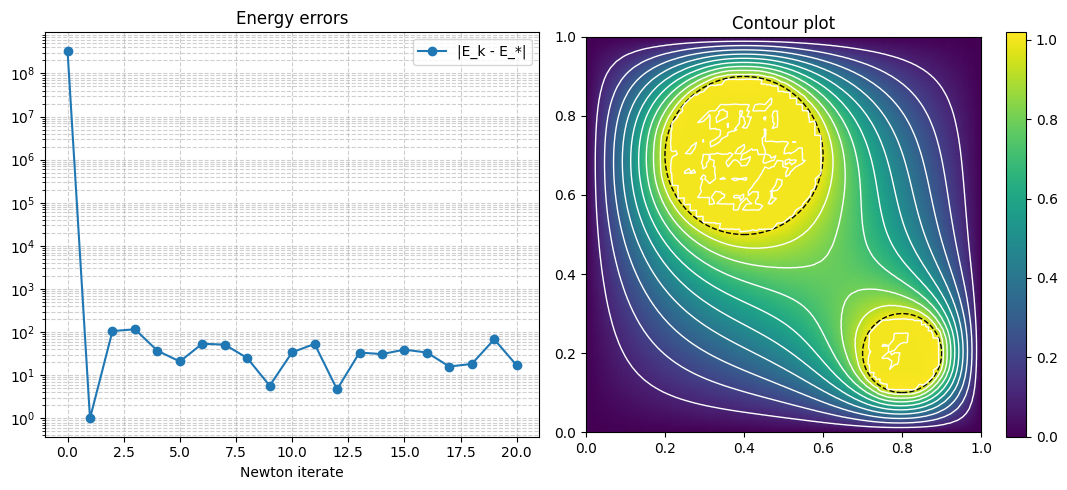

In [98]:
u, energies = constrained_optimisation()

2. For nonlinear problems with many solutions, initial guesses may lie outside any basin of attraction.

3. At very high order, nonlinearity makes assembly costly.

Let's discuss a pretty robust alternative...

## **Back to basics:** Gradient descent (GD)

Let's restrict our attention to energy minimisation problems.
You might not have seen GD in the function space setting before, but the idea's identical.
Instead of the update
$$
\mathbf{x}_{n+1} = \mathbf{x}_n - h\nabla E(\mathbf{x}_n),
$$
we have
$$
(u_{n+1}, v) = (u_n, v) - hE'(\mathbf{x}_n; v).
$$

Key facts:
- Converges for fixed step sizes in (0, 2/L), with L the Lipschitz constant of \nabla E.
- Only requires one lower level of regularity than Newton.
- The linear operator to invert in function spaces is the inner product; often identical across steps.
- Global convergence to a minimizer for convex energies regardless of start.